In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/reddit_dead_internet_analysis_2026.csv")
df.head()

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,contains_links,is_bot_flag,bot_type_label,bot_probability
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,False,False,None (Human),0.093
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,False,False,None (Human),0.117
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,False,False,None (Human),0.115
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,False,False,None (Human),0.094
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,False,False,None (Human),0.116


In [3]:
df.shape

(500, 11)

In [11]:
df.isnull().sum()

,0
account_age_days,0
user_karma,0
reply_delay_seconds,0
sentiment_score,0
avg_word_length,0
contains_links,0
label,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,contains_links
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1157.624000,25248.198000,1030.700000,0.014980,5.654300,0.228000
std,951.766304,14122.969163,1184.411096,0.581127,0.895203,0.419963
min,1.000000,308.000000,1.000000,-1.000000,4.030000,0.000000
25%,163.000000,13427.250000,7.000000,-0.472500,4.967500,0.000000
50%,1092.500000,24778.500000,459.000000,0.020000,5.695000,0.000000
75%,1960.000000,37111.500000,1925.000000,0.502500,6.250000,0.000000
max,2996.000000,49734.000000,3577.000000,1.000000,7.490000,1.000000


In [4]:
df.columns

Index(['comment_id', 'subreddit', 'account_age_days', 'user_karma',
       'reply_delay_seconds', 'sentiment_score', 'avg_word_length',
       'contains_links', 'is_bot_flag', 'bot_type_label', 'bot_probability'],
      dtype='object')

In [5]:
df = df.drop(columns=[
    "comment_id",
    "subreddit",
    "bot_type_label",
    "bot_probability"
])

In [6]:
df["contains_links"] = df["contains_links"].astype(int)

In [7]:
df = df.rename(columns={"is_bot_flag": "label"})

In [8]:
df.head()

,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,contains_links,label
0,2264,34192,1854,-0.60,4.62,0,False
1,1654,2812,1033,0.15,5.84,0,False
2,2442,37109,2703,0.35,5.73,0,False
3,168,32997,2811,-0.74,4.58,0,False
4,801,25088,1721,-0.96,5.78,0,False


In [9]:
df["label"].value_counts()

,count
label,
False,282
True,218


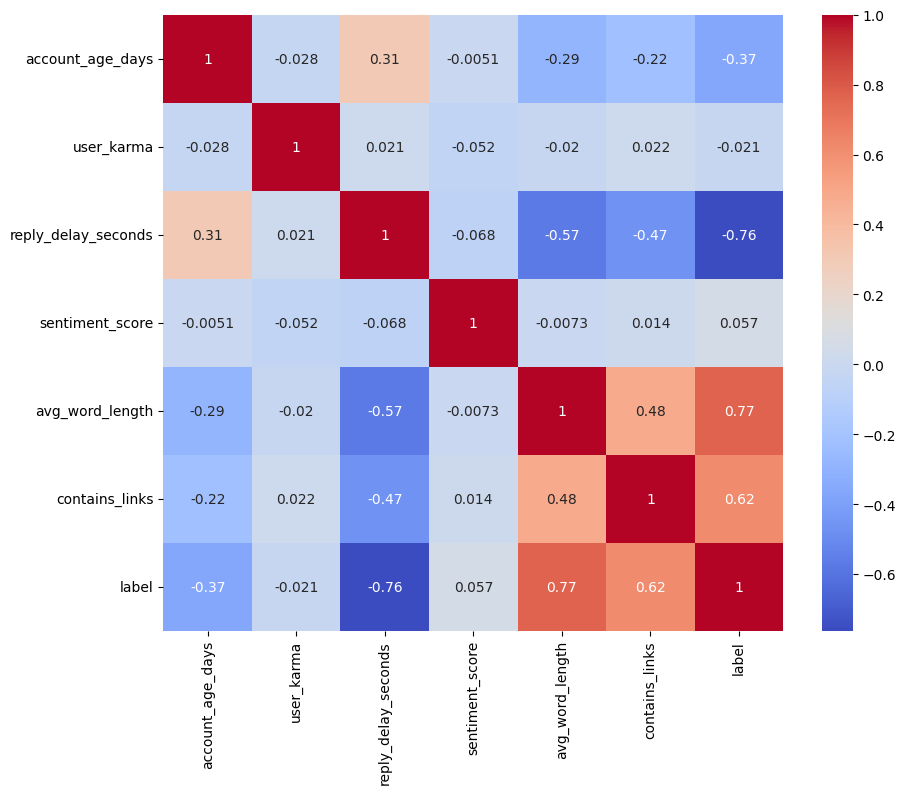

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [14]:
df["reply_speed"] = 1 / (df["reply_delay_seconds"] + 1)

In [15]:
df["karma_per_day"] = df["user_karma"] / (df["account_age_days"] + 1)

In [16]:
df.head()

,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,contains_links,label,reply_speed,karma_per_day
0,2264,34192,1854,-0.60,4.62,0,False,0.000539,15.095806
1,1654,2812,1033,0.15,5.84,0,False,0.000967,1.699094
2,2442,37109,2703,0.35,5.73,0,False,0.000370,15.189930
3,168,32997,2811,-0.74,4.58,0,False,0.000356,195.248521
4,801,25088,1721,-0.96,5.78,0,False,0.000581,31.281796


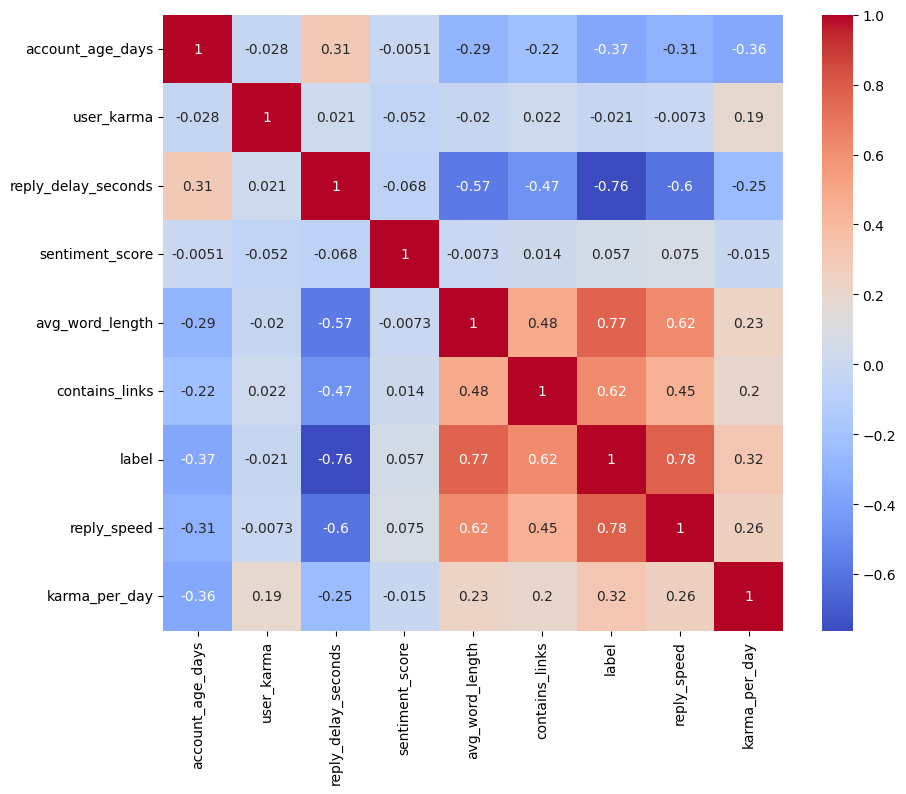

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [18]:
X = df.drop("label", axis=1)
y = df["label"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [21]:
lr_pred = lr_model.predict(X_test)
accuracy_score(y_test, lr_pred)

1.0

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

accuracy_score(y_test, rf_pred)

1.0

In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

accuracy_score(y_test, xgb_pred)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:45:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1.0